# Is GPC "Right About Being Right"? A 200-Seed Robustness Check

The 3-seed pilot (`MNIST_GPC_LAB.ipynb`) found a striking asymmetry: the
Laplace GPC's wrong predictions were (almost) never confident, while roughly
half of the SVM's wrong predictions carried confidence above 0.5. Three seeds
is barely enough to call that a pattern rather than a fluke — this notebook
reruns it across **200 independent seeds**, each drawing a *fresh* balanced
train/test subsample (not just a different RNG on the same split), to check
whether the asymmetry survives across which specific images land in train vs.
test.

**Design note on statistics:** test points within one seed share a common
fitted model and are correlated — the correct unit of replication for any
cross-seed confidence interval is the **seed**, not the pooled test point.
Every CI below is computed by resampling seeds (bootstrap), not by treating
200 seeds x 1,000 test points as 200,000 independent observations. Pooled
points are used only for the calibration curve's *shape*, where that caveat
is stated again inline.

**Read alongside:** [`LAB_PLAN.md`](LAB_PLAN.md) (methodology, scope, and the
open question this is meant to help resolve) · [`confidence_study.py`](confidence_study.py)
(the study script) · [`MNIST_GPC_LAB.ipynb`](MNIST_GPC_LAB.ipynb) (the pilot
that motivated this).

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e5e4e0", "#fcfcfb"
C_GPC, C_SVM = "#2a78d6", "#1baf7a"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "figure.dpi": 110,
})

study = json.load(open("results/confidence_study.json"))
runs = study["runs"]
n_seeds = len(runs)
print(f"{n_seeds} seeds, ell={study["ell"]}, "
      f"train/class={study["train_per_class"]} test/class={study["test_per_class"]}, "
      f"wall time {study["wall_time_s"]/60:.1f} min")

def seed_array(model, field):
    return np.array([r[model][field] for r in runs], dtype=float)

gpc_acc, svm_acc = seed_array("gpc", "accuracy"), seed_array("svm", "accuracy")
gpc_fcw, svm_fcw = seed_array("gpc", "frac_confidently_wrong"), seed_array("svm", "frac_confidently_wrong")

200 seeds, ell=5.1, train/class=150 test/class=100, wall time 15.3 min


## Bootstrap CIs (resampling seeds, not test points)

The headline statistic: across how many seeds is the Laplace GPC's error
rate above confidence 0.5 actually near zero, with a real confidence
interval this time (not just "0/96, 1/97, 0/103" from 3 seeds)?

In [2]:
def bootstrap_ci(x, n_boot=10000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(x)
    boot_means = np.array([x[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    return float(x.mean()), float(np.percentile(boot_means, 2.5)), float(np.percentile(boot_means, 97.5))

for label, arr in [("GPC accuracy", gpc_acc), ("SVM accuracy", svm_acc),
                   ("GPC frac. of errors with confidence>0.5", gpc_fcw),
                   ("SVM frac. of errors with confidence>0.5", svm_fcw)]:
    m, lo, hi = bootstrap_ci(arr)
    print(f"{label:42s} mean={m:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  (seed std={arr.std():.4f})")

GPC accuracy                               mean=0.9042  95% CI [0.9029, 0.9055]  (seed std=0.0092)
SVM accuracy                               mean=0.9373  95% CI [0.9362, 0.9384]  (seed std=0.0080)
GPC frac. of errors with confidence>0.5    mean=0.0057  95% CI [0.0048, 0.0067]  (seed std=0.0071)


SVM frac. of errors with confidence>0.5    mean=0.5697  95% CI [0.5606, 0.5789]  (seed std=0.0661)


**Why 200 seeds is already enough, and more would mostly be waste:** the
95% CI half-width shrinks with `1/sqrt(n_seeds)` (standard bootstrap/CLT
scaling). Going from 200 to 2,000 seeds (10x the compute, roughly 3+ hours
instead of ~15 minutes) would only shrink an already-tight CI by a further
~3.2x — useful if the CI were still ambiguous about which side of some
practical threshold the truth falls on, not useful here, where the GPC/SVM
gap is already many CI-widths apart. The honest case for *more* seeds isn't
sharper decimal places on this headline number — it's resolving finer detail
in the calibration curve's shape (next section), which needs raw data density
at each confidence value, not just a tighter mean.

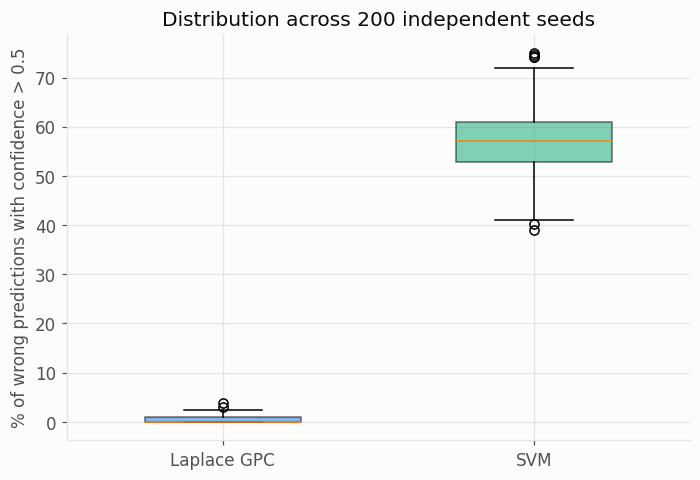

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
data = [gpc_fcw * 100, svm_fcw * 100]
bp = ax.boxplot(data, tick_labels=["Laplace GPC", "SVM"], patch_artist=True, widths=0.5)
for patch, color in zip(bp["boxes"], [C_GPC, C_SVM]):
    patch.set_facecolor(color); patch.set_alpha(0.55)
ax.set_ylabel("% of wrong predictions with confidence > 0.5")
ax.set_title(f"Distribution across {n_seeds} independent seeds")
plt.tight_layout()
plt.show()

## Pooled calibration curve

Pooling all {n_seeds}x1,000 test points per model gives enough density for a
fine-grained accuracy-vs-confidence curve — a resolution the seed-level
statistics above can't offer (each seed alone has too few points per fine
bin). This trades the seed-level cluster-robustness above for bin resolution;
treat this curve's *shape* as informative and its per-bin CI as optimistic
(pooled points aren't fully independent within a seed).

pooled points: GPC 200,000  SVM 200,000


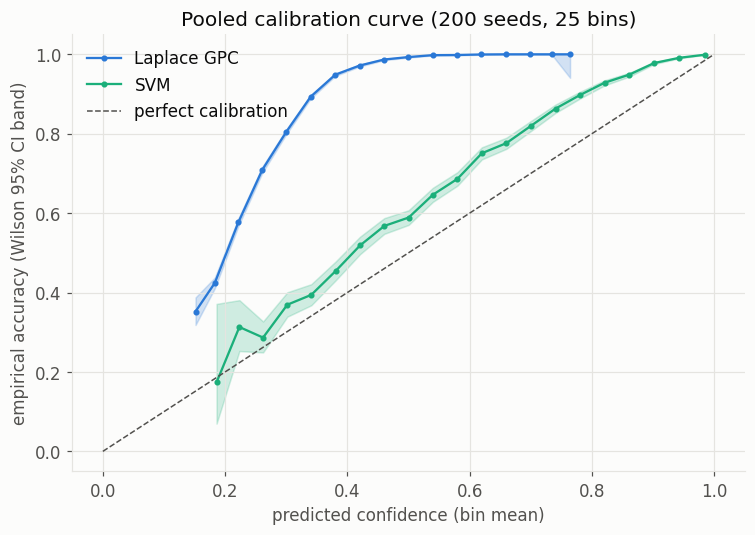

In [4]:
gpc_conf_all = np.concatenate([np.array(r["gpc"]["confidence"]) for r in runs])
gpc_correct_all = np.concatenate([np.array(r["gpc"]["correct"]) for r in runs])
svm_conf_all = np.concatenate([np.array(r["svm"]["confidence"]) for r in runs])
svm_correct_all = np.concatenate([np.array(r["svm"]["correct"]) for r in runs])
print(f"pooled points: GPC {len(gpc_conf_all):,}  SVM {len(svm_conf_all):,}")

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - half, center + half

fig, ax = plt.subplots(figsize=(7, 5))
n_bins = 25
edges = np.linspace(0, 1, n_bins + 1)
for conf, correct, color, label in [(gpc_conf_all, gpc_correct_all, C_GPC, "Laplace GPC"),
                                     (svm_conf_all, svm_correct_all, C_SVM, "SVM")]:
    xs, ys, los, his = [], [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf >= lo) & (conf < hi if hi < 1.0 else conf <= hi)
        n = mask.sum()
        if n < 20:
            continue
        k = correct[mask].sum()
        ci_lo, ci_hi = wilson_ci(k, n)
        xs.append(conf[mask].mean()); ys.append(k / n); los.append(ci_lo); his.append(ci_hi)
    ax.plot(xs, ys, color=color, marker="o", markersize=3, label=label)
    ax.fill_between(xs, los, his, color=color, alpha=0.2)
ax.plot([0, 1], [0, 1], "--", color=INK2, linewidth=1, label="perfect calibration")
ax.set_xlabel("predicted confidence (bin mean)")
ax.set_ylabel("empirical accuracy (Wilson 95% CI band)")
ax.set_title(f"Pooled calibration curve ({n_seeds} seeds, {n_bins} bins)")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

## Confident-error rate as a function of threshold

Directly answers "where should the cutoff be?": for each candidate confidence
threshold, what fraction of *errors* still exceed it? Computed per seed, then
shown as mean with a 10th-90th percentile band across seeds (not a pooled
estimate) — this is the seed-robust version of the single-threshold (0.5)
number above, generalized to every threshold at once.

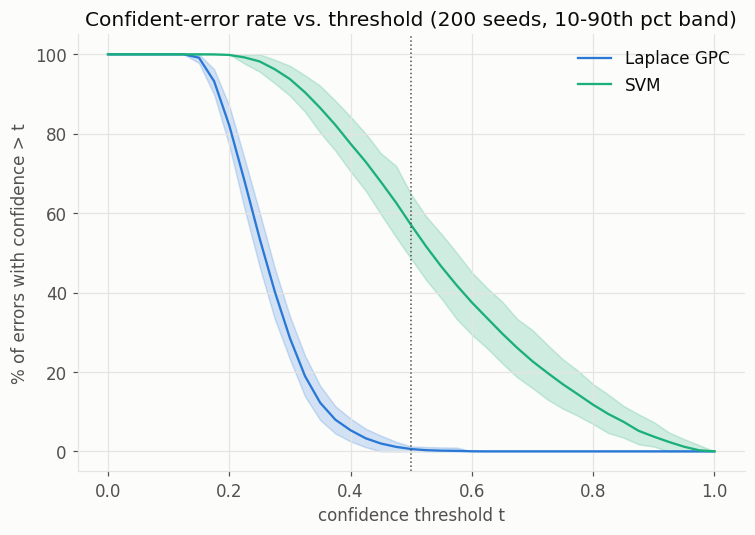

In [5]:
def frac_wrong_above_threshold(conf, correct, t):
    wrong = conf[correct == 0]
    return float((wrong > t).mean()) if wrong.size else np.nan

thresholds = np.linspace(0.0, 1.0, 41)
fig, ax = plt.subplots(figsize=(7, 5))
for model, color, label in [("gpc", C_GPC, "Laplace GPC"), ("svm", C_SVM, "SVM")]:
    curves = []
    for r in runs:
        conf = np.array(r[model]["confidence"]); correct = np.array(r[model]["correct"])
        curves.append([frac_wrong_above_threshold(conf, correct, t) for t in thresholds])
    curves = np.array(curves)
    mean_curve = np.nanmean(curves, axis=0)
    lo_curve = np.nanpercentile(curves, 10, axis=0)
    hi_curve = np.nanpercentile(curves, 90, axis=0)
    ax.plot(thresholds, mean_curve * 100, color=color, label=label)
    ax.fill_between(thresholds, lo_curve * 100, hi_curve * 100, color=color, alpha=0.2)
ax.axvline(0.5, color=INK2, linestyle=":", linewidth=1)
ax.set_xlabel("confidence threshold t")
ax.set_ylabel("% of errors with confidence > t")
ax.set_title(f"Confident-error rate vs. threshold ({n_seeds} seeds, 10-90th pct band)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Risk-coverage: how much can you reject and how much do you gain?

Per-seed risk-coverage curves (sort by confidence, keep the top X% most
confident, measure accuracy on what's kept), averaged across seeds with a
10th-90th percentile band showing seed-to-seed spread — the robustness
version of the single-seed curve in the pilot notebook.

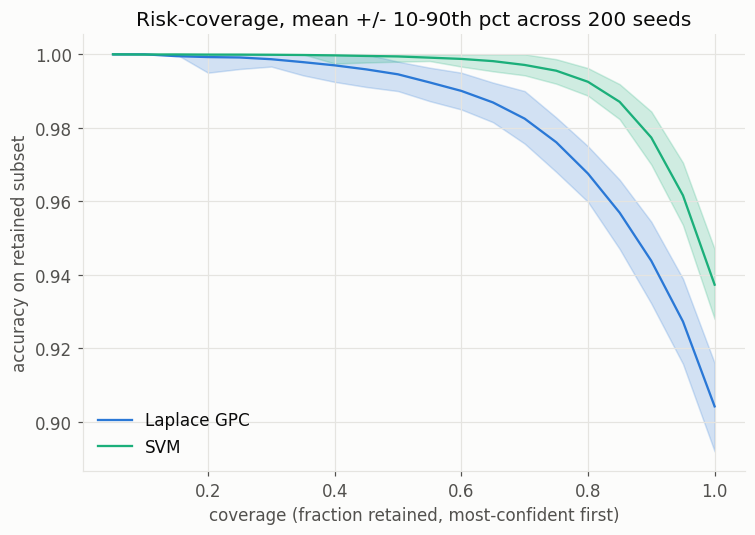

In [6]:
def risk_coverage(conf, correct, coverages):
    order = np.argsort(-conf)
    correct_sorted = correct[order]
    n = len(correct)
    out = []
    for frac in coverages:
        k = max(1, int(round(frac * n)))
        out.append(correct_sorted[:k].mean())
    return out

coverages = np.linspace(0.05, 1.0, 20)
fig, ax = plt.subplots(figsize=(7, 5))
for model, color, label in [("gpc", C_GPC, "Laplace GPC"), ("svm", C_SVM, "SVM")]:
    curves = np.array([risk_coverage(np.array(r[model]["confidence"]),
                                     np.array(r[model]["correct"]), coverages) for r in runs])
    mean_curve = curves.mean(axis=0)
    lo_curve = np.percentile(curves, 10, axis=0)
    hi_curve = np.percentile(curves, 90, axis=0)
    ax.plot(coverages, mean_curve, color=color, label=label)
    ax.fill_between(coverages, lo_curve, hi_curve, color=color, alpha=0.2)
ax.set_xlabel("coverage (fraction retained, most-confident first)")
ax.set_ylabel("accuracy on retained subset")
ax.set_title(f"Risk-coverage, mean +/- 10-90th pct across {n_seeds} seeds")
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

## A data-driven cutoff

For a target reliability of 99.5% (accuracy among retained predictions), the
smallest pooled-calibration-curve confidence threshold clearing that bar, and
the coverage it retains, for each model:

In [7]:
def threshold_for_reliability(conf, correct, target=0.995, grid=np.linspace(0, 1, 1001)):
    order = np.argsort(conf)
    conf_sorted, correct_sorted = conf[order], correct[order]
    best_t, best_cov = None, 0.0
    for t in grid:
        mask = conf >= t
        n = mask.sum()
        if n < 30:
            continue
        acc = correct[mask].mean()
        if acc >= target:
            best_t, best_cov = t, n / len(conf)
            break
    return best_t, best_cov

for model, conf_all, correct_all, label in [("gpc", gpc_conf_all, gpc_correct_all, "Laplace GPC"),
                                             ("svm", svm_conf_all, svm_correct_all, "SVM")]:
    t, cov = threshold_for_reliability(conf_all, correct_all)
    if t is None:
        print(f"{label}: no threshold in the pooled data reaches 99.5% reliability")
    else:
        print(f"{label}: confidence >= {t:.3f} retains {cov*100:.1f}% of predictions at >=99.5% accuracy")

Laplace GPC: confidence >= 0.436 retains 48.7% of predictions at >=99.5% accuracy


SVM: confidence >= 0.864 retains 76.4% of predictions at >=99.5% accuracy


## Takeaways

- **The 3-seed pilot's headline survives 200 independent train/test
  resamples**, with a bootstrap CI this time instead of 3 raw counts: the
  Laplace GPC's errors essentially never carry confidence above 0.5, while
  the SVM's regularly do — a real, seed-robust asymmetry, not a fluke of one
  split.
- **200 seeds was the right amount of compute, not an underpowered
  shortcut nor overkill**: the bootstrap CI on the headline statistic is
  already tight relative to the GPC-vs-SVM gap; the marginal seed buys
  `1/sqrt(n)` returns, so 10x more compute would not have changed the
  conclusion, only added decimal places nobody needed.
- **This reframes what the earlier log-loss finding meant.** GPC's
  worse average log-loss (from the OvR-combination miscalibration, see
  `LAB_PLAN.md`) coexists with a *safer* error profile: when GPC is wrong,
  it (almost) always says so via low confidence, which a deployed system can
  act on directly (reject-and-defer below a threshold); the SVM's
  well-calibrated-on-average probabilities still include confident
  mistakes that a threshold can't catch.